In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import f_oneway
import time
from itertools import combinations

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, brier_score_loss

import mlacca_functions as mlcf

# hide the "y_pred contains classes not in y_true" UserWarning from sklearn as it is expected when using different definitions
from warnings import filterwarnings
filterwarnings("ignore",module="sklearn",category=UserWarning)

In [2]:
df_path = 'data\\csv_files\\new_vk_areas_df.csv'

comparison_plots_output_folder = 'data\\plots\\comparisons'
csv_folder = 'data\\csv_files'

weighted = True
show_title = False

In [3]:
df = pd.read_csv(df_path)

In [4]:
# Functions

def test_model_accuracy(model,X,y,repeats=50, classifier_name='[DEFAULT]', title=None,
                        xlabel=None,ylabel=None,colors_dict=None):

    accuracies = []

    for i in range(repeats):
        X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
        weights_rdm_train, weights_rdm_test = mlcf.train_test(X, y,random_state=None)

        fitted_model = model.fit(X_rdm_train, y_rdm_train, sample_weight=weights_rdm_train if weighted else None)

        accuracies.append(balanced_accuracy_score(y_true = y_rdm_test,
                                                y_pred = fitted_model.predict(X_rdm_test),
                                                sample_weight=weights_rdm_test if weighted else None,
                                                ))

        if accuracies[i] == np.max(accuracies):
            max_model = fitted_model
            X_rdm_train_best = X_rdm_train
            y_rdm_train_best = y_rdm_train

    print(f'''Average accuracy of the {classifier_name} classifier trained on {len(X_rdm_train)} samples (run {repeats} times): {np.mean(accuracies)} +/- {np.std(accuracies)}
Max accuracy: {np.max(accuracies)}
Min accuracy: {np.min(accuracies)}
Random Accuracy: {1/len(np.unique(y_rdm_train))}''')

    if np.shape(X)[1] == 2:
        mlcf.draw_decision_boundary_plot(max_model,
                                    X_rdm_train_best,
                                    categories=np.unique(y_rdm_train_best),
                                    xlabel=xlabel,
                                    ylabel=ylabel,
                                    colors_dict=colors_dict,
                                    title=title
                                    )


def fitting_runtime(iterations:int,model,X,y,weights) -> float:

    times = []

    for i in range(iterations):
        start_time = time.time()
        fit = model.fit(X, y, sample_weight=weights)
        runtime = time.time() - start_time

        times.append(runtime)

    return sum(times)/iterations


def draw_violinplot(data_dict, ylabel, title=None, savepath=None, colours=[],hline=None,
                    xlabel_rotation=45,ha='right',figsize=(6.4, 4.8)):

    labels = list(data_dict.keys())
    data = list(data_dict.values())

    fig, ax = plt.subplots(figsize=figsize)

    parts = ax.violinplot(data,
                          showmeans=False, showmedians=False,
                          showextrema=False)

    if len(colours)>0:
        if len(colours)==1:
            colours = colours * len(labels)
        assert len(colours)==len(labels), "Number of colours must match number of violin plots"
        for pc,c in zip(parts['bodies'],colours):
            pc.set_facecolor(c)
            pc.set_edgecolor('black')
            pc.set_alpha(1)

    quartile1, medians, quartile3 = np.percentile(np.array(data), [25, 50, 75], axis=1)

    inds = np.arange(1, len(medians) + 1)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3, edgecolors='k')
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(np.arange(1,len(labels)+1), labels, rotation=xlabel_rotation, ha=ha, fontsize=12)

    if hline:
        if type(hline) in [list, tuple]:
            for hl in hline:
                ax.axhline(y=hl, color='r', linestyle='--', lw=1)
        else:
            ax.axhline(y=hline, color='r', linestyle='--', lw=1)

    if title: ax.set_title(title, fontsize=14)
    if savepath: fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

    return fig, ax


def correlation_matrix(data_dict, threshold=0.05, savepath=None, title=None,
                       colours=['tab:orange','tab:blue']):

    # first colour for p <= threshold (significant difference),
    # second for p > threshold (not significant difference)

    labels = list(data_dict.keys())

    p_dict = {}
    for comb in list(combinations(labels,2)):
        p_dict[f'{comb[0]},{comb[1]}'] = f_oneway(*[data_dict[comb[0]],data_dict[comb[1]]],nan_policy='omit')[1]

    # draw a binary correlation matrix plot of the p values and colour only the values < 0.05
    p_matrix = pd.DataFrame(np.ones((len(labels),len(labels))), index=labels, columns=labels)
    p_matrix[p_matrix == 1] = np.nan
    for comb in list(combinations(labels,2)):
        p_value = p_dict[f'{comb[0]},{comb[1]}']
        p_matrix.loc[comb[0], comb[1]] = np.nan
        p_matrix.loc[comb[1], comb[0]] = p_value

    p_matrix[(p_matrix > threshold)&(p_matrix.notna())] = 1
    p_matrix[(p_matrix <= threshold)&(p_matrix.notna())] = 0

    fig, ax = plt.subplots()

    cmap = mpl.colors.ListedColormap(colours)

    cax = ax.matshow(p_matrix, cmap=cmap)

    for label, colour in zip([f'$p\\leq{threshold}$', f'$p>{threshold}$'], colours):
        ax.scatter(None, None, c=colour, label=label,marker='s',s=100)

    ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)

    ax.set_xticks(np.arange(len(labels)-1), labels[:-1], rotation=45,horizontalalignment='right')
    ax.set_yticks(np.arange(1,len(labels)), labels[1:])
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xlim(-0.5, len(labels)-1.5)
    ax.set_ylim(len(labels)-0.5, 0.5)

    if title: ax.set_title(title, fontsize=14)
    if savepath: fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

    return fig, ax


def set_y_ticks(data_dict,ax,major_ticks_interval=0.1,minor_ticks_interval=0.05,rounding=2):
    ylim = (np.round(np.floor(10**rounding*np.min(list(data_dict.values())))/10**rounding,rounding)-10**-rounding, 1)
    ax.set_ylim(ylim)
    
    ax.set_yticks(np.arange(np.round(np.floor(1e2*ylim[0])/1e2,1),ylim[1]+0.01, major_ticks_interval))

    ax.tick_params(axis='y', which='minor')
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(minor_ticks_interval))

In [5]:
columns_2d = ['O/C','H/C']#, 'N/C', 'S/C', 'P/C']
X_2d = df[columns_2d].to_numpy()

columns_3d = ['O/C','H/C','N/C']
X_3d = df[columns_3d].to_numpy()

y = df['category'].to_numpy()
weights = df['weights'].to_numpy() if weighted else None

multiclass_colors=[mlcf.vk_region_colours[cat] for cat in np.unique(y)]

In [6]:
# comparison of these models with literature models

In [7]:
rivas_ubach_adj_cat = df['category'].copy().to_numpy()

for cat in ['lignin','tannin']:
    rivas_ubach_adj_cat[np.where(rivas_ubach_adj_cat == cat)] = 'phytochemical'

rivas_ubach_class_weights = compute_class_weight('balanced', classes=np.unique(rivas_ubach_adj_cat), y=rivas_ubach_adj_cat)
rivas_ubach_class_weights_dict = {cls: weight for cls, weight in zip(np.unique(rivas_ubach_adj_cat), rivas_ubach_class_weights)}
rivas_ubach_weights = [rivas_ubach_class_weights_dict[cat] for cat in rivas_ubach_adj_cat]

In [8]:
# test the model accuracies using the same slices of the overall dataset and plot boxplots and do ANOVA on the results

clf_models = {
    'GNB (W)': CalibratedClassifierCV(GaussianNB()),
    'Poly SVM (W)': CalibratedClassifierCV(SVC(kernel="poly", **mlcf.svm_poly_param_3d)),
    'RBF SVM (W)': CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_3d)),
}

clf_models_unweighted = {x.replace('(W)','(U)'):clf_models[x] for x in clf_models}
clf_models_unweighted['KNN'] = mlcf.knn_pipeline(mlcf.knn_param_3d)

lit_models = {
    'DBCCR': mlcf.laszakovits_mackay_areas,
    'Adjusted MSCC': mlcf.ru_lm_areas,
}

phyto_clf_models = {f'{x} (R-U)' : clf_models[x] for x in clf_models}

phyto_clf_models_unweighted = {f'{x} (R-U)' : clf_models_unweighted[x] for x in clf_models_unweighted}

phyto_lit_model = {'MSCC': mlcf.rivasubach_areas,}

models_list = list(lit_models.keys()) + list(clf_models_unweighted.keys()) + list(clf_models.keys()) +\
              list(phyto_lit_model.keys()) + list(phyto_clf_models_unweighted.keys()) + list(phyto_clf_models.keys())

In [9]:
accuracies_dict = {name: [] for name in models_list}
balanced_accuracies_dict = {name: [] for name in models_list}
zero_rule_acc = []

repeats = 40

iteration_dict = {'non_r-u':{'definition':y,'modeltypes':[clf_models, clf_models_unweighted, lit_models]},
                  'r-u':{'definition':rivas_ubach_adj_cat,'modeltypes':[phyto_clf_models, phyto_clf_models_unweighted, phyto_lit_model]}}

for n in range(repeats):
    print(f'Accuracy test iteration {n+1} of {repeats}')
    
    for definition_type in iteration_dict:
        X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
        weights_rdm_train, weights_rdm_test = mlcf.train_test(X_3d, iteration_dict[definition_type]['definition'], random_state=None)

        if definition_type == 'non_r-u':
            zero_rule_class = np.unique(y_rdm_test)[np.argmax([len(np.where(y_rdm_test==cat)[0]) for cat in np.unique(y_rdm_test)])]
            zero_rule_acc.append(accuracy_score(y_true=y_rdm_test,
                                                y_pred=[zero_rule_class]*len(y_rdm_test),
                                                normalize=True))

        for modeltype in iteration_dict[definition_type]['modeltypes']:

            for model in modeltype:
                
                print(f'{n+1}/{repeats}\tTesting model: {model}')

                sample_weight = dict(sample_weight=weights_rdm_train) if weighted and modeltype == clf_models else None

                fit_args = dict(X=X_rdm_train, y=y_rdm_train)
                if weighted and modeltype in [clf_models,phyto_clf_models]: fit_args['sample_weight'] = weights_rdm_train

                clf = modeltype[model].fit(**fit_args) if modeltype not in [lit_models,phyto_lit_model] else None

                y_pred = clf.predict(X_rdm_test) if modeltype not in [lit_models,phyto_lit_model]\
                         else mlcf.molecclass(pd.DataFrame(X_rdm_test, columns=columns_3d), areas=lit_models[model] if modeltype == lit_models else phyto_lit_model[model],
                                              dims=columns_3d if 'DBCCR' not in model else columns_2d)

                for accuracy_type in [[accuracy_score, dict(normalize=True), accuracies_dict],
                                      [balanced_accuracy_score, dict(sample_weight=weights_rdm_test if weighted else None), balanced_accuracies_dict]]:
                    
                    acc = accuracy_type[0](y_true=y_rdm_test,
                                           y_pred=y_pred,
                                           **accuracy_type[1])
                    accuracy_type[2][model].append(acc)

                print(f'\t\taccuracy: {accuracies_dict[model][-1]}, balanced accuracy: {balanced_accuracies_dict[model][-1]}')


Accuracy test iteration 1 of 40
1/40	Testing model: GNB (W)
		accuracy: 0.737281067556297, balanced accuracy: 0.9215736883290075
1/40	Testing model: Poly SVM (W)
		accuracy: 0.8882402001668057, balanced accuracy: 0.9388355930909121
1/40	Testing model: RBF SVM (W)
		accuracy: 0.890742285237698, balanced accuracy: 0.9393163623216814
1/40	Testing model: GNB (U)
		accuracy: 0.9241034195162635, balanced accuracy: 0.5496056101109292
1/40	Testing model: Poly SVM (U)
		accuracy: 0.9474562135112594, balanced accuracy: 0.7527990675597058
1/40	Testing model: RBF SVM (U)
		accuracy: 0.9608006672226855, balanced accuracy: 0.7778646196199389
1/40	Testing model: KNN
		accuracy: 0.9649708090075062, balanced accuracy: 0.8416706126812511
1/40	Testing model: DBCCR
		accuracy: 0.6013344453711427, balanced accuracy: 0.6674610259716646
1/40	Testing model: Adjusted MSCC
		accuracy: 0.8857381150959133, balanced accuracy: 0.7406246531246531
1/40	Testing model: GNB (W) (R-U)
		accuracy: 0.7948290241868223, bala

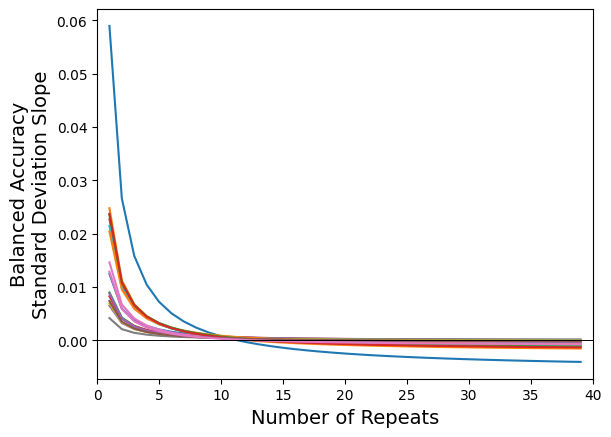

In [10]:
# Plot the derivative of std vs number of repeats.
# This is to help decide on a reasonable number of repeats for future tests.

SAVE = True

def fitting_func(x, a, c):
    return (a / x) + c

curves_list = []

for model in models_list:
    fig, ax = plt.subplots()

    n_of_times = range(1,len(balanced_accuracies_dict[model])+1)

    step_wise_stds = [np.std(balanced_accuracies_dict[model][:i]) for i in n_of_times]

    y_axis = np.diff(step_wise_stds)/np.diff(n_of_times)

    ax.scatter(n_of_times[:-1], y_axis,marker='.', alpha=0.7)

    popt, pcov = curve_fit(fitting_func, n_of_times[:-1], y_axis)
    curves_list.append(fitting_func(np.array(n_of_times[:-1]), *popt))
    ax.plot(n_of_times[:-1], curves_list[-1], 'r--', label=f'$y={popt[1]:.4f}+\\frac{{{popt[0]:.4f}}}{{x}}$')
    ax.legend(fontsize=14)

    if show_title:
        ax.set_title(f'{model}\nAccuracy Standard Deviation Slope vs Number of Repeats', fontsize=14)
    ax.set_xlabel('Number of Repeats',fontsize=14)
    ax.set_ylabel('Balanced Accuracy\nStandard Deviation Slope',fontsize=14)
    ax.set_xlim(0, len(balanced_accuracies_dict[model]))

    ax.axhline(0,lw=.7,c='k')

    if SAVE:
        fig.savefig(f'{comparison_plots_output_folder}\\accuracy_std_vs_repeats\\balanced_accuracy_std_slope_vs_repeats_{model.replace(' ','_')}.png', dpi=600, facecolor='#fff', bbox_inches='tight')

    plt.close()

fig, ax = plt.subplots()
for curve in curves_list:
    ax.plot(range(1,len(balanced_accuracies_dict[model])), curve)
if show_title:
    ax.set_title(f'All Models\nAccuracy Standard Deviation Slope vs Number of Repeats', fontsize=14)
ax.set_xlabel('Number of Repeats',fontsize=14)
ax.set_ylabel('Balanced Accuracy\nStandard Deviation Slope',fontsize=14)
ax.set_xlim(0, len(balanced_accuracies_dict[model]))
ax.axhline(0,lw=.7,c='k')
if SAVE:
    fig.savefig(f'{comparison_plots_output_folder}\\accuracy_std_vs_repeats\\balanced_accuracy_std_slope_vs_repeats_all_models.png', dpi=600, facecolor='#fff', bbox_inches='tight')

In [11]:
# adjust accuracies_dict values by the chance of random guessing
chance_balanced_accuracies_dict = {}

for key in balanced_accuracies_dict:
    number_of_categories = len(np.unique(y)) if key not in list(phyto_lit_model.keys()) + list(phyto_clf_models.keys()) else len(np.unique(rivas_ubach_adj_cat))

    chance = 1 / number_of_categories

    chance_balanced_accuracies_dict[key] = [(acc-chance)/(1 - chance) for acc in balanced_accuracies_dict[key] ]

In [12]:
comparison_df = pd.DataFrame({
    'model':[model.replace('$', '').replace('\\', '') for model in models_list],
    'mean_accuracy':[np.mean(accuracies_dict[model]) for model in models_list],
    'std_accuracy':[np.std(accuracies_dict[model]) for model in models_list],
    'median_accuracy':[np.median(accuracies_dict[model]) for model in models_list],
    'mean_balanced_accuracy':[np.mean(balanced_accuracies_dict[model]) for model in models_list],
    'std_balanced_accuracy':[np.std(balanced_accuracies_dict[model]) for model in models_list],
    'median_balanced_accuracy':[np.median(balanced_accuracies_dict[model]) for model in models_list],
    'mean_chance_balanced_accuracy':[np.mean(chance_balanced_accuracies_dict[model]) for model in models_list],
    'std_chance_balanced_accuracy':[np.std(chance_balanced_accuracies_dict[model]) for model in models_list],
    'median_chance_balanced_accuracy':[np.median(chance_balanced_accuracies_dict[model]) for model in models_list],
})

comparison_df.to_csv(f'{csv_folder}\\model_performance_comparison.csv', index=False)
# comparison_df

In [13]:
# boxplot_colors = []
boxplot_colors_dict = {'Literature Models':'gold',
                       'Unweighted Supervised\nClassifier Models':'lightcoral',
                       'Weighted Supervised\nClassifier Models':'skyblue',}
zero_rule_colour = 'grey'

def model_colour(model):
    if '(W)' in model:
        return boxplot_colors_dict['Weighted Supervised\nClassifier Models']
    elif any([x in model for x in ['DBCCR','MSCC']]):
        return boxplot_colors_dict['Literature Models']
    elif any([x in model for x in ['(U)','KNN']]):
        return boxplot_colors_dict['Unweighted Supervised\nClassifier Models']
    else: return zero_rule_colour

plot_type = {'boxplot':mlcf.draw_boxplot,
             'violinplot':draw_violinplot}

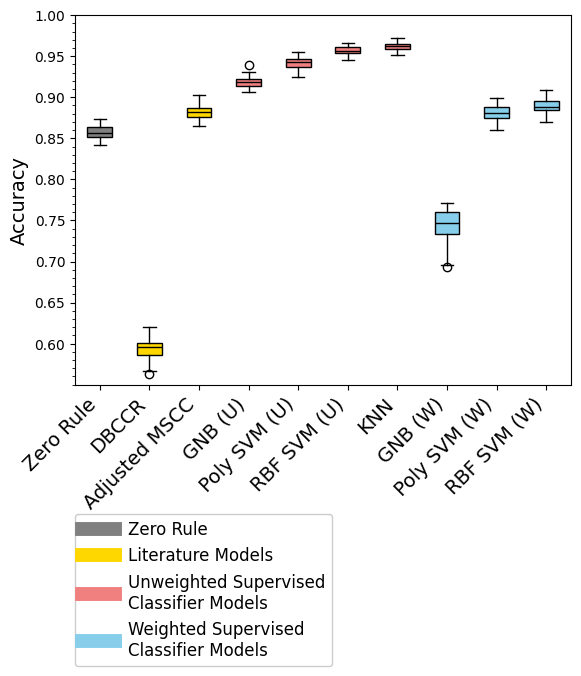

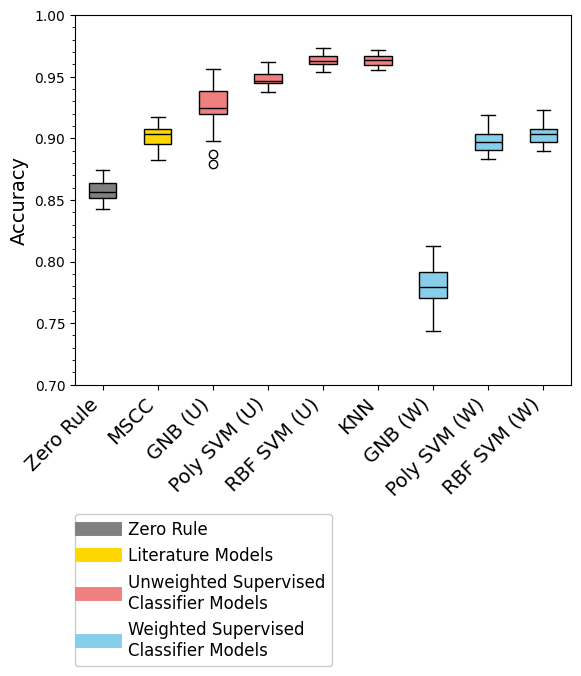

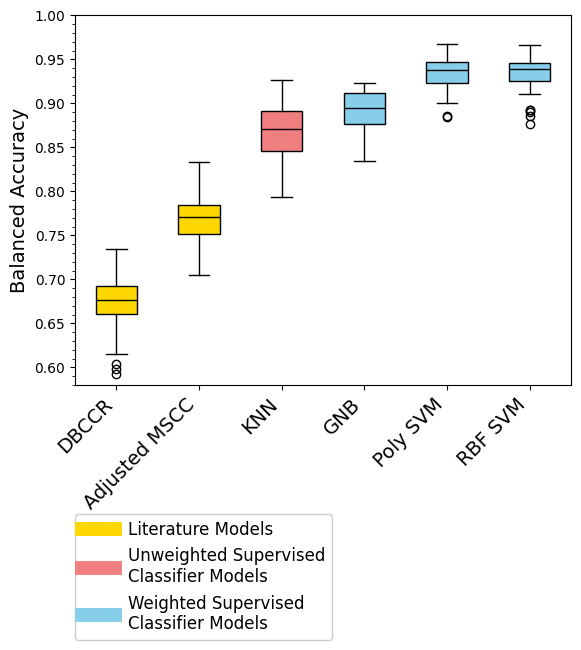

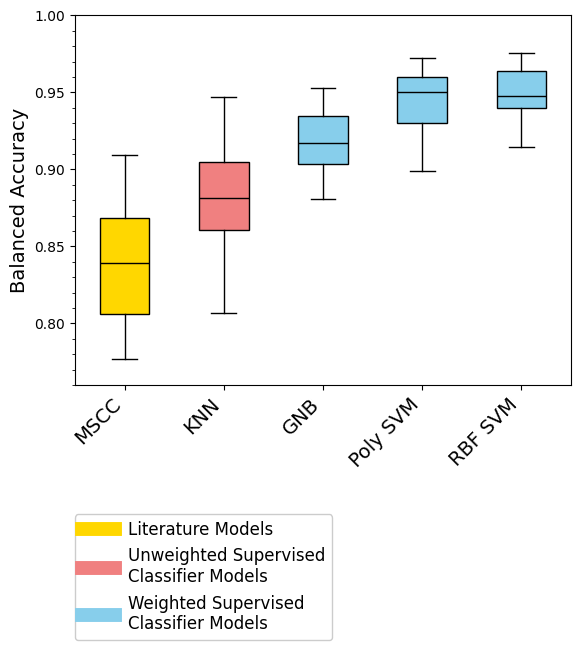

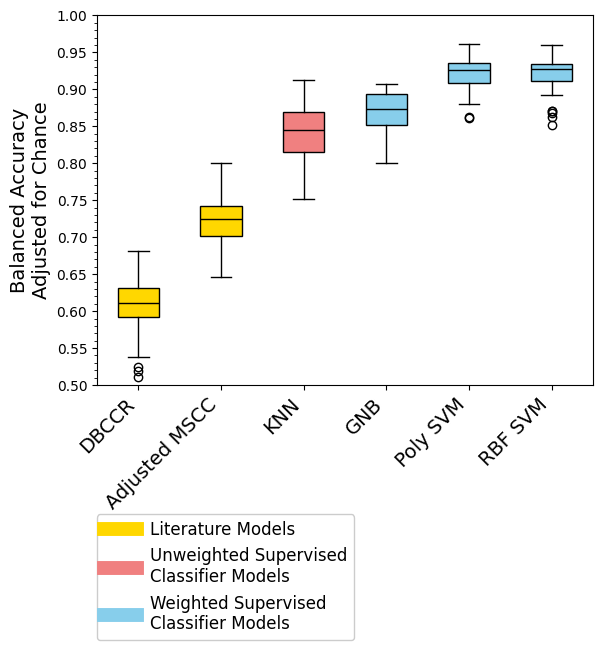

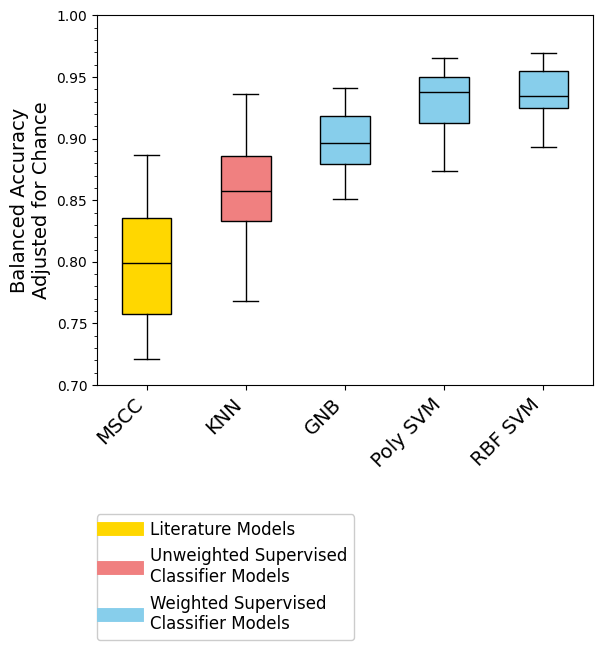

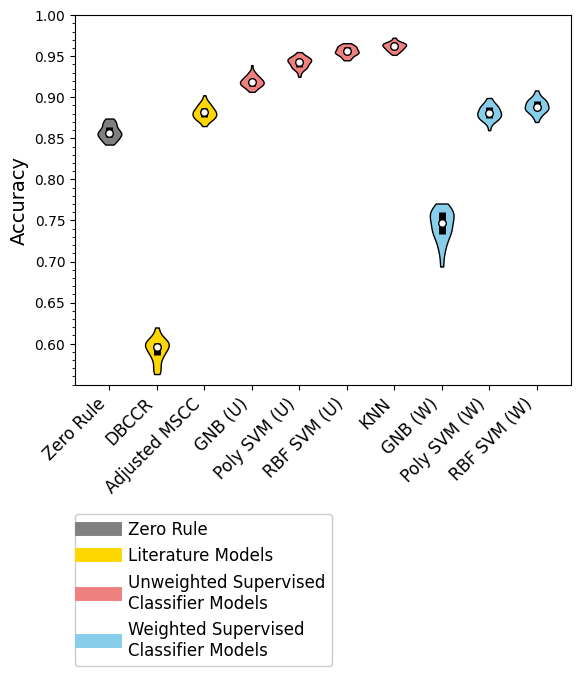

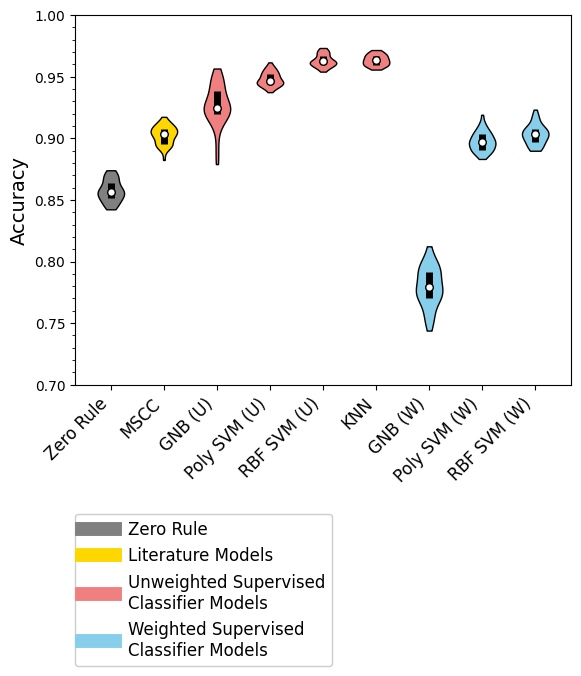

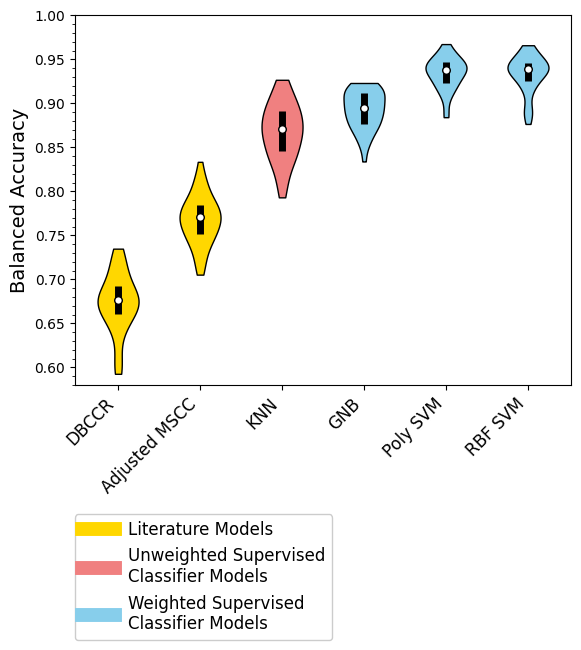

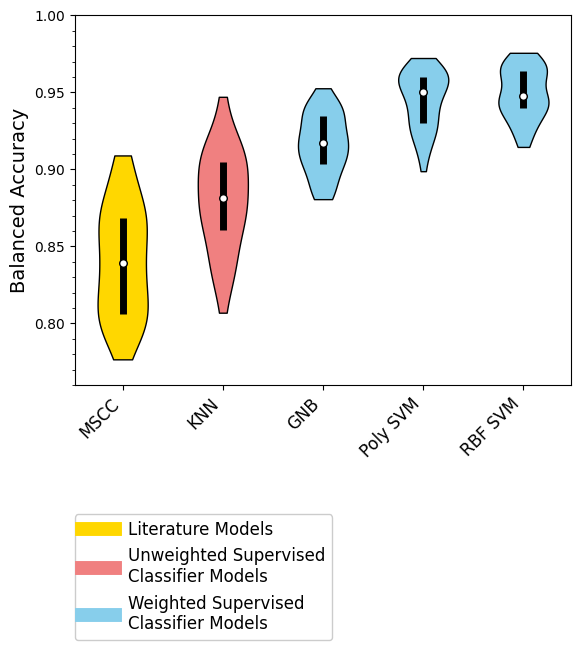

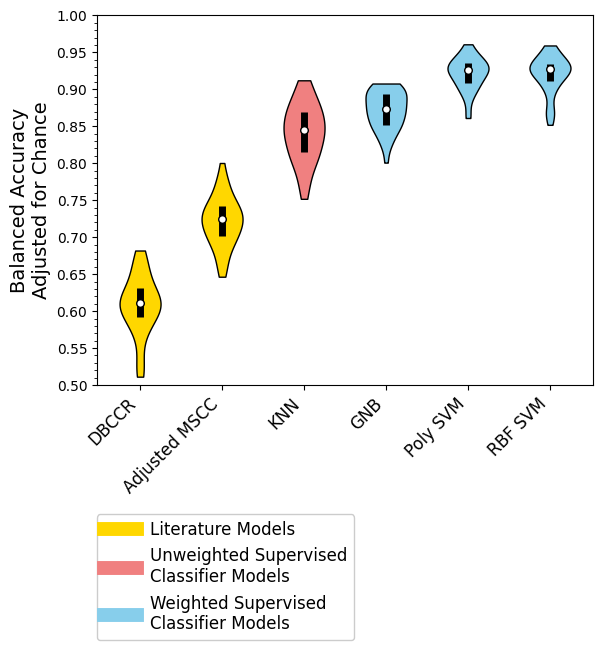

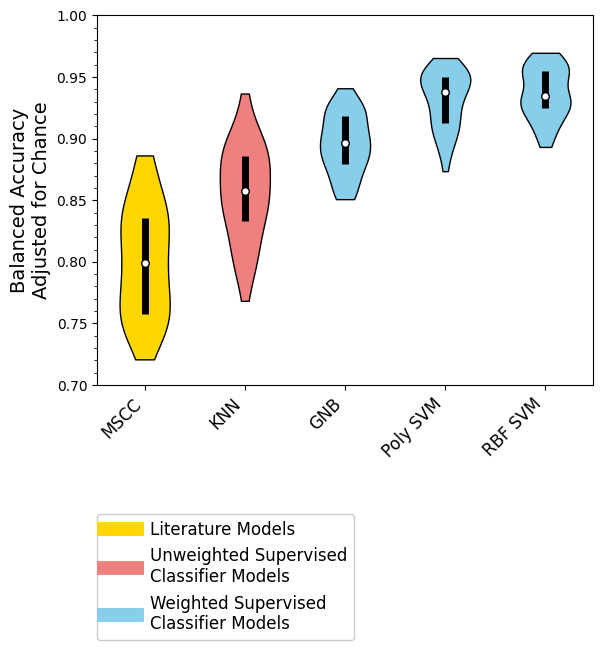

In [14]:
data_dict = {'raw':accuracies_dict,
             'balanced':balanced_accuracies_dict,
             'chance':chance_balanced_accuracies_dict}

figsize=(10,4.8) # width, height

def ru_bool(x):
    return 'R-U' in x or ('MSCC' in x and 'Adjusted' not in x)

hide_unweighted = True

for plot_choice in plot_type:
    for acc_type in data_dict.keys():
        
        if acc_type == 'raw':
            ylabel = 'Accuracy'

            data_to_use = {}
            data_to_use['Zero Rule'] = zero_rule_acc
            # colours_to_use = [zero_rule_colour] + boxplot_colors
            for x in accuracies_dict: data_to_use[x] = accuracies_dict[x]
        
        elif acc_type == 'balanced':
            ylabel = 'Balanced Accuracy'
            data_to_use = balanced_accuracies_dict
            # colours_to_use = boxplot_colors
        
        elif acc_type == 'chance':
            ylabel = 'Balanced Accuracy\nAdjusted for Chance'
            data_to_use = chance_balanced_accuracies_dict
            # colours_to_use = boxplot_colors
        
        if hide_unweighted and acc_type!='raw':
            data_to_use = {x:data_to_use[x] for x in data_to_use if '(U)' not in x}

        for ru_defs in [False,True]:

            if ru_defs:
                data_to_use_ru = {x.replace(' (R-U)',''):data_to_use[x] for x in data_to_use.keys() if ru_bool(x) or x == 'Zero Rule'}
            else:
                data_to_use_ru = {x:data_to_use[x] for x in data_to_use.keys() if not ru_bool(x)}

            boxplot_colors = [model_colour(x) for x in data_to_use_ru.keys()]

            if acc_type != 'raw' and hide_unweighted:
                data_to_use_ru = {x.replace(' (W)',''):data_to_use_ru[x] for x in data_to_use_ru}

            fig, ax = plot_type[plot_choice](data_to_use_ru,
                                             ylabel=ylabel,
                                             colours=boxplot_colors,)
            
            set_y_ticks(data_to_use_ru,ax,major_ticks_interval=0.05,minor_ticks_interval=0.01,rounding=2)

            if acc_type == 'raw':
                # ax.scatter(None, None, c=zero_rule_colour,  label='Zero Rule', edgecolors='k')
                ax.plot([None], [None], c=zero_rule_colour, label='Zero Rule', lw=10)

            for c in boxplot_colors_dict:
                if boxplot_colors_dict[c] in boxplot_colors:
                    ax.plot([None], [None], c=boxplot_colors_dict[c], label=c, lw=10)
            
            title = f'Comparison of the {ylabel.replace('\n',' ')} of Assignment\nbetween Literature and Classifier Models'
            fig_path = f'{comparison_plots_output_folder}\\acc_comparison_{plot_choice}_{acc_type}'
            if ru_defs:
                fig_path += '_rivas-ubach'
                title += '\n(R-U Definitions)'

            if show_title:
                ax.set_title(title,fontsize=16)

            ax.legend(framealpha=1,bbox_to_anchor=(0,-.35), loc='upper left', borderaxespad=0, fontsize=12)
            
            fig.savefig(f'{fig_path}.svg',dpi=600, facecolor='#fff', bbox_inches='tight')

## Now fit models by adding another category: PAHs.

In [15]:
df_with_pahs_path = f'{csv_folder}\\new_vk_areas_with_pahs.csv'

In [16]:
df_with_pahs = pd.read_csv(df_with_pahs_path)

In [17]:
X_with_pahs_2d = df_with_pahs[columns_2d].to_numpy()
X_with_pahs_3d = df_with_pahs[columns_3d].to_numpy()

y_with_pahs = df_with_pahs['category'].to_numpy()
weights_with_pahs = df_with_pahs['weights'].to_numpy() if weighted else None

In [18]:
clf_models_with_pahs = {
    'GNB (W)': CalibratedClassifierCV(GaussianNB()),
    'Poly SVM (W)': CalibratedClassifierCV(SVC(kernel="poly", **mlcf.svm_poly_param_3d_with_PAHs)),
    'RBF SVM (W)': CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_3d_with_PAHs)),
}

clf_models_with_pahs_unweighted = {x.replace('(W)','(U)'):clf_models_with_pahs[x] for x in clf_models_with_pahs}
clf_models_with_pahs_unweighted['KNN'] = mlcf.knn_pipeline(mlcf.knn_param_3d_with_PAHs)

models_with_pahs_list = list(clf_models_with_pahs_unweighted.keys()) + list(clf_models_with_pahs.keys())

In [19]:
accuracies_dict_with_pahs = {name: [] for name in models_with_pahs_list}
balanced_accuracies_dict_with_pahs = {name: [] for name in models_with_pahs_list}
zero_rule_with_pahs_acc = []

repeats = 40

columns = columns_3d

for n in range(repeats):
    print(f'Accuracy test iteration {n+1} of {repeats}')

    zero_rule_class = np.unique(y_rdm_test)[np.argmax([len(np.where(y_rdm_test==cat)[0]) for cat in np.unique(y_rdm_test)])]
    zero_rule_with_pahs_acc.append(accuracy_score(y_true=y_rdm_test,
                                                  y_pred=[zero_rule_class]*len(y_rdm_test),
                                                  normalize=True))

    X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
    weights_rdm_train, weights_rdm_test = mlcf.train_test(X_with_pahs_3d, y_with_pahs,random_state=None)

    for modeltype in [clf_models_with_pahs,clf_models_with_pahs_unweighted]:

        for model in modeltype:

            print(f'{n+1}/{repeats}\tTesting model: {model}')

            fit_args = dict(X=X_rdm_train, y=y_rdm_train)
            if weighted and modeltype == clf_models_with_pahs: fit_args['sample_weight'] = weights_rdm_train

            y_pred = modeltype[model].fit(**fit_args).predict(X_rdm_test)

            for accuracy_type in [[accuracy_score, dict(normalize=True), accuracies_dict_with_pahs],
                                  [balanced_accuracy_score, dict(sample_weight=weights_rdm_test if weighted else None), balanced_accuracies_dict_with_pahs]]:

                acc = accuracy_type[0](y_true=y_rdm_test,
                                       y_pred=y_pred,
                                       **accuracy_type[1])
                accuracy_type[2][model].append(acc)

            print(f'\t\taccuracy: {accuracies_dict_with_pahs[model][-1]}, balanced accuracy: {balanced_accuracies_dict_with_pahs[model][-1]}')


Accuracy test iteration 1 of 40
1/40	Testing model: GNB (W)
		accuracy: 0.7639802631578947, balanced accuracy: 0.9333273549526522
1/40	Testing model: Poly SVM (W)
		accuracy: 0.8782894736842105, balanced accuracy: 0.9390504089586031
1/40	Testing model: RBF SVM (W)
		accuracy: 0.8963815789473685, balanced accuracy: 0.9490452027854269
1/40	Testing model: GNB (U)
		accuracy: 0.9259868421052632, balanced accuracy: 0.6354568728336155
1/40	Testing model: Poly SVM (U)
		accuracy: 0.9383223684210527, balanced accuracy: 0.6813705250886481
1/40	Testing model: RBF SVM (U)
		accuracy: 0.9547697368421053, balanced accuracy: 0.807989514169385
1/40	Testing model: KNN
		accuracy: 0.9580592105263158, balanced accuracy: 0.8952535549568871
Accuracy test iteration 2 of 40
2/40	Testing model: GNB (W)
		accuracy: 0.7376644736842105, balanced accuracy: 0.8985147326855837
2/40	Testing model: Poly SVM (W)
		accuracy: 0.8791118421052632, balanced accuracy: 0.9476160799319354
2/40	Testing model: RBF SVM (W)
		ac

In [20]:
chance_balanced_accuracies_dict_with_pahs = {}
for key in balanced_accuracies_dict_with_pahs:
    number_of_categories = len(np.unique(y_with_pahs))

    chance = 1 / number_of_categories

    chance_balanced_accuracies_dict_with_pahs[key] = [(acc-chance)/(1 - chance) for acc in balanced_accuracies_dict_with_pahs[key] ]

comparison_with_pahs_df = pd.DataFrame({
    'model':[model.replace('$', '').replace('\\', '') for model in models_with_pahs_list],
    'mean_accuracy':[np.mean(accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'std_accuracy':[np.std(accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'median_accuracy':[np.median(accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'mean_balanced_accuracy':[np.mean(balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'std_balanced_accuracy':[np.std(balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'median_balanced_accuracy':[np.median(balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'mean_chance_balanced_accuracy':[np.mean(chance_balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'std_chance_balanced_accuracy':[np.std(chance_balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'median_chance_balanced_accuracy':[np.median(chance_balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
})

comparison_with_pahs_df.to_csv(f'{csv_folder}\\model_performance_comparison_with_pahs.csv', index=False)

In [21]:
boxplot_with_pahs_colors = []

for model in models_with_pahs_list:
    if model in clf_models_with_pahs:
        boxplot_with_pahs_colors.append(boxplot_colors_dict['Weighted Supervised\nClassifier Models'])
    elif model in clf_models_with_pahs_unweighted:
        boxplot_with_pahs_colors.append(boxplot_colors_dict['Unweighted Supervised\nClassifier Models'])
zero_rule_colour = 'grey'

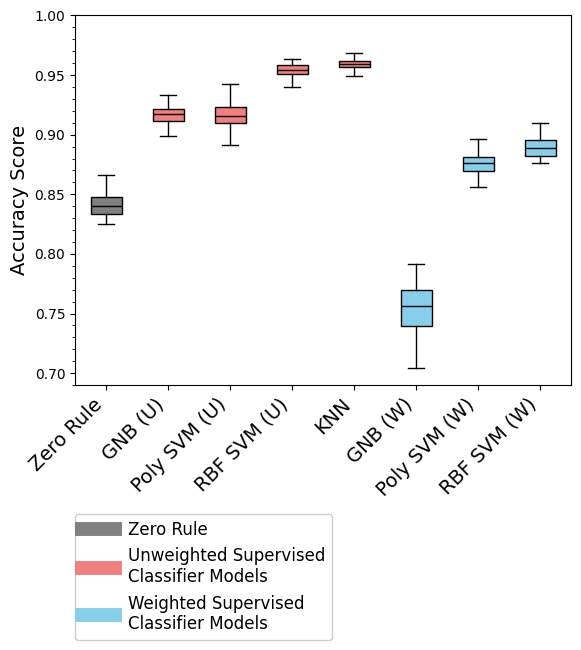

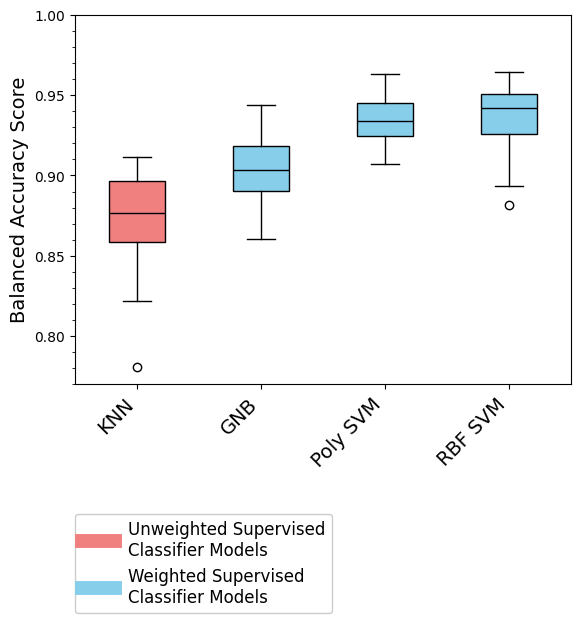

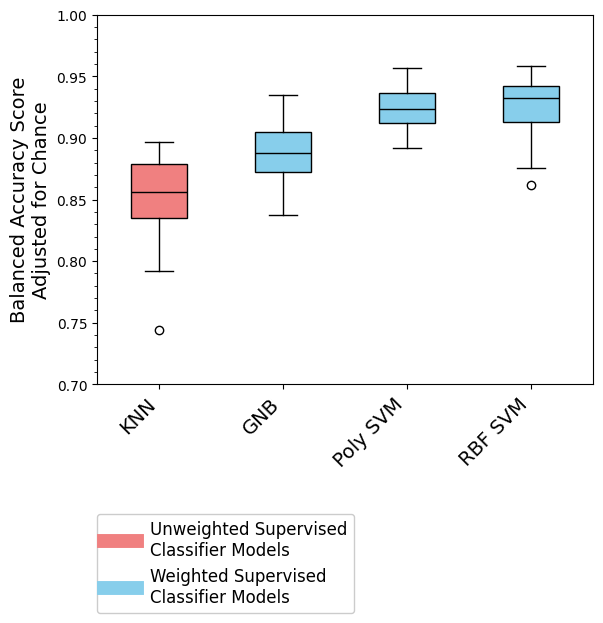

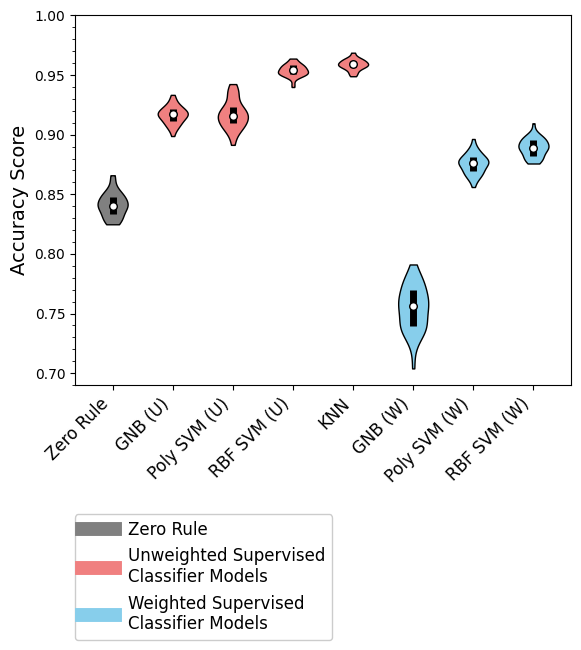

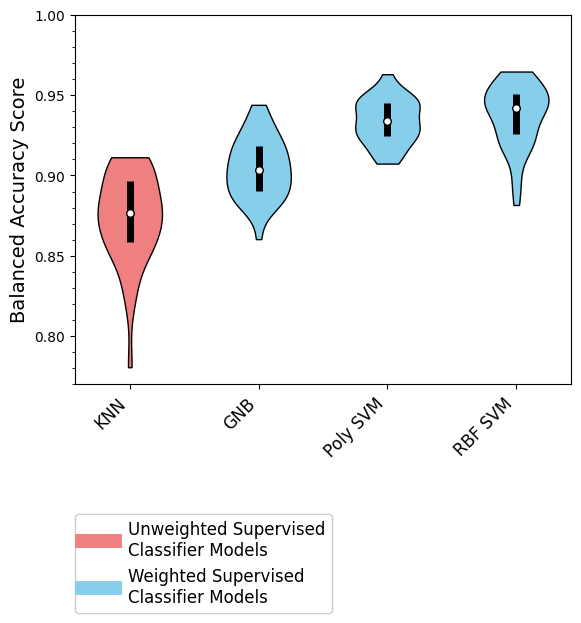

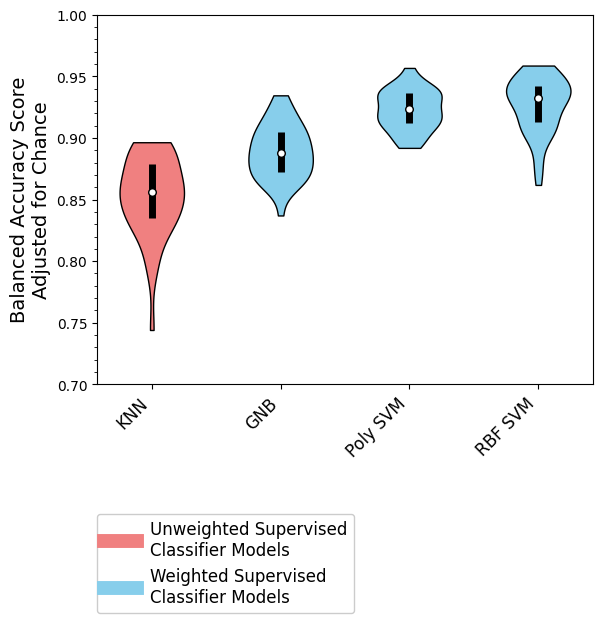

In [22]:
data_dict_with_pahs = {'raw':accuracies_dict_with_pahs,
                       'balanced':balanced_accuracies_dict_with_pahs,
                       'chance':chance_balanced_accuracies_dict_with_pahs}

figsize=None#(10,4.8)

hide_unweighted = True

for plot_choice in plot_type:
    for acc_type in data_dict_with_pahs.keys():
        if acc_type == 'raw':
            ylabel = 'Accuracy Score'

            data_to_use = {}
            data_to_use['Zero Rule'] = zero_rule_with_pahs_acc
            colours_to_use = [zero_rule_colour] + boxplot_with_pahs_colors
            
            for x in accuracies_dict_with_pahs: data_to_use[x] = accuracies_dict_with_pahs[x]
        
        elif acc_type == 'balanced':
            ylabel = 'Balanced Accuracy Score'
            data_to_use = balanced_accuracies_dict_with_pahs
            colours_to_use = boxplot_with_pahs_colors
        
        elif acc_type == 'chance':
            ylabel = 'Balanced Accuracy Score\nAdjusted for Chance'
            data_to_use = chance_balanced_accuracies_dict_with_pahs
            colours_to_use = boxplot_with_pahs_colors

        if hide_unweighted and acc_type != 'raw':
            data_to_use = {x:data_to_use[x] for x in data_to_use if '(U)' not in x}
            colours_to_use = [model_colour(x) for x in data_to_use]

        if acc_type != 'raw' and hide_unweighted:
             data_to_use = {x.replace(' (W)',''):data_to_use[x] for x in data_to_use}

        fig, ax = plot_type[plot_choice](data_to_use,
                                         ylabel=ylabel,
                                         colours=colours_to_use,
                                         figsize=figsize,
                                         savepath=f'{comparison_plots_output_folder}\\acc_comparison_with_pahs_{plot_choice}_{acc_type}.svg',
                                         )
        
        set_y_ticks(data_to_use,ax,major_ticks_interval=0.05,
                    minor_ticks_interval=0.01,rounding=2)
        
        if acc_type == 'raw':
            ax.plot([None], [None], c=zero_rule_colour, label='Zero Rule', lw=10)

        for c in boxplot_colors_dict:
            if boxplot_colors_dict[c] in boxplot_with_pahs_colors:
                ax.plot([None], [None], c=boxplot_colors_dict[c], label=c, lw=10)
        
        if show_title:
            ax.set_title(f'Comparison of the {ylabel.replace('\n',' ')} of Assignment\nbetween Classifier Models Including PAHs' if show_title else None,
                         fontsize=16)

        ax.legend(framealpha=1,bbox_to_anchor=(0, -.35), loc='upper left', borderaxespad=0,fontsize=12)
        fig.savefig(f'{comparison_plots_output_folder}\\acc_comparison_with_pahs_{plot_choice}_{acc_type}.svg',
                    dpi=600, facecolor='#fff', bbox_inches='tight')

In [23]:
# Compare the Brier score loss of different classifier models

brier_score_loss_dict = {model: [] for model in models_with_pahs_list}

repeats = 40

for n in range(repeats):

    for modeltype in [clf_models_with_pahs,clf_models_with_pahs_unweighted]:

        for model in modeltype:

            print(f'{n+1}/{repeats}\tTesting model: {model}')

            X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
            weights_rdm_train, weights_rdm_test = mlcf.train_test(X_with_pahs_3d, y_with_pahs,random_state=None)

            fit_args = dict(X=X_rdm_train, y=y_rdm_train)
            if weighted and modeltype == clf_models_with_pahs: fit_args['sample_weight'] = weights_rdm_train

            y_proba = modeltype[model].fit(**fit_args).predict_proba(X_rdm_test)

            brier_score_loss_dict[model].append(brier_score_loss(y_rdm_test,y_proba,sample_weight=weights_rdm_test))

            print(f'\tBrier score loss = {brier_score_loss_dict[model][-1]}')

1/40	Testing model: GNB (W)
	Brier score loss = 0.11488585894619088
1/40	Testing model: Poly SVM (W)
	Brier score loss = 0.09087794895259173
1/40	Testing model: RBF SVM (W)
	Brier score loss = 0.15771064154578243
1/40	Testing model: GNB (U)
	Brier score loss = 0.48985572041164416
1/40	Testing model: Poly SVM (U)
	Brier score loss = 0.5682770447784623
1/40	Testing model: RBF SVM (U)
	Brier score loss = 0.3082934033424152
1/40	Testing model: KNN
	Brier score loss = 0.2214737813244222
2/40	Testing model: GNB (W)
	Brier score loss = 0.15331070212673822
2/40	Testing model: Poly SVM (W)
	Brier score loss = 0.16396347006792863
2/40	Testing model: RBF SVM (W)
	Brier score loss = 0.09616436366965972
2/40	Testing model: GNB (U)
	Brier score loss = 0.5817475478341698
2/40	Testing model: Poly SVM (U)
	Brier score loss = 0.5984764963895985
2/40	Testing model: RBF SVM (U)
	Brier score loss = 0.32908318033364453
2/40	Testing model: KNN
	Brier score loss = 0.21767990691411612
3/40	Testing model: GNB (

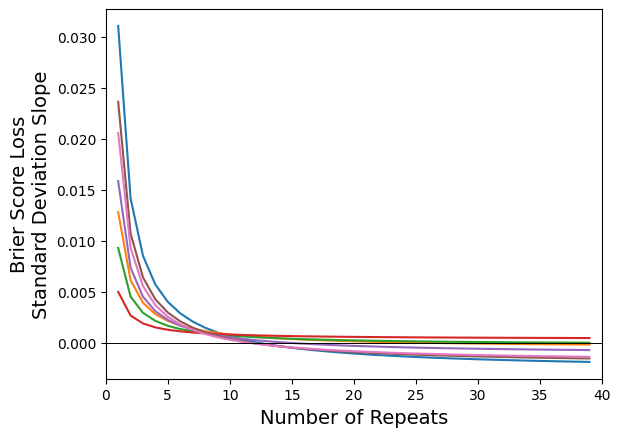

In [24]:
# Plot the derivative of Brier score loss vs number of repeats.
# This is to help decide on a reasonable number of repeats for future tests.

SAVE = True

def fitting_func(x, a, b, c):
    return a * (b * x)**(-1) + c

curves_list = []

for model in brier_score_loss_dict.keys():
    fig, ax = plt.subplots()

    n_of_times = range(1,len(brier_score_loss_dict[model])+1)

    step_wise_stds = [np.std(brier_score_loss_dict[model][:i]) for i in n_of_times]

    y_axis = np.diff(step_wise_stds)/np.diff(n_of_times)

    ax.scatter(n_of_times[:-1], y_axis,marker='.', alpha=0.7)

    popt, pcov = curve_fit(fitting_func, n_of_times[:-1], y_axis)
    curves_list.append(fitting_func(np.array(n_of_times[:-1]), *popt))
    ax.plot(n_of_times[:-1], curves_list[-1], 'r--', label=f'${popt[0]}*\\frac{{1}}{{{popt[1]}}}*x + {popt[2]}$')

    if show_title:
        ax.set_title(f'{model}\nBrier Score Loss Standard Deviation Slope vs Number of Repeats', fontsize=14)
    ax.set_xlabel('Number of Repeats')
    ax.set_ylabel('Brier Score Loss Standard Deviation Slope')
    ax.set_xlim(0, len(brier_score_loss_dict[model]))

    ax.axhline(0,lw=.7,c='k')

    if SAVE:
        fig.savefig(f'{comparison_plots_output_folder}\\bsl_std_vs_repeats\\bsl_std_slope_vs_repeats_{model.replace(' ','_')}.png', dpi=600, facecolor='#fff', bbox_inches='tight')

    plt.close()

fig, ax = plt.subplots()
for curve in curves_list:
    ax.plot(range(1,len(brier_score_loss_dict[model])), curve)
if show_title:
    ax.set_title(f'All Models\nBrier Score Loss Standard Deviation Slope vs Number of Repeats', fontsize=14)
ax.set_xlabel('Number of Repeats',fontsize=14)
ax.set_ylabel('Brier Score Loss\nStandard Deviation Slope',fontsize=14)
ax.set_xlim(0, len(brier_score_loss_dict[model]))
ax.axhline(0,lw=.7,c='k')
if SAVE:
    fig.savefig(f'{comparison_plots_output_folder}\\bsl_std_vs_repeats\\bsl_std_slope_vs_repeats_all_models.png', dpi=600, facecolor='#fff', bbox_inches='tight')

In [25]:
brier_score_loss_dict.keys()
brier_score_loss_df = pd.DataFrame({
    'model': [x for x in brier_score_loss_dict],
    'mean_bsl':[np.mean(brier_score_loss_dict[x]) for x in brier_score_loss_dict],
    'std_bsl':[np.std(brier_score_loss_dict[x]) for x in brier_score_loss_dict],
    'median_bsl':[np.median(brier_score_loss_dict[x]) for x in brier_score_loss_dict],
})
brier_score_loss_df.to_csv(f'{csv_folder}\\bsl.csv', index=False)

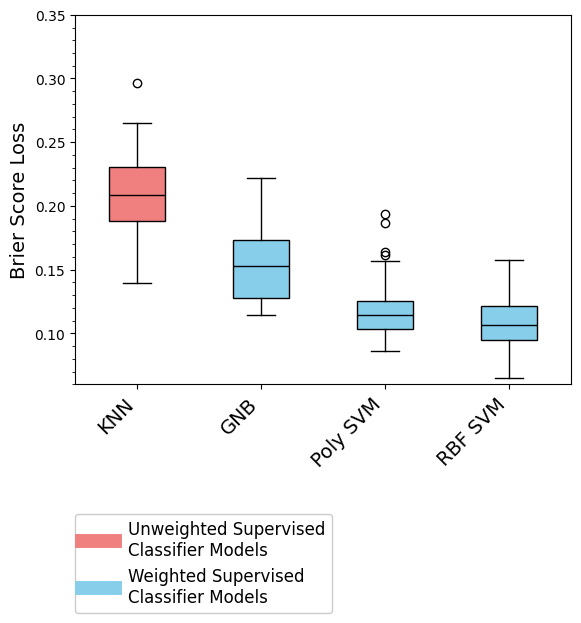

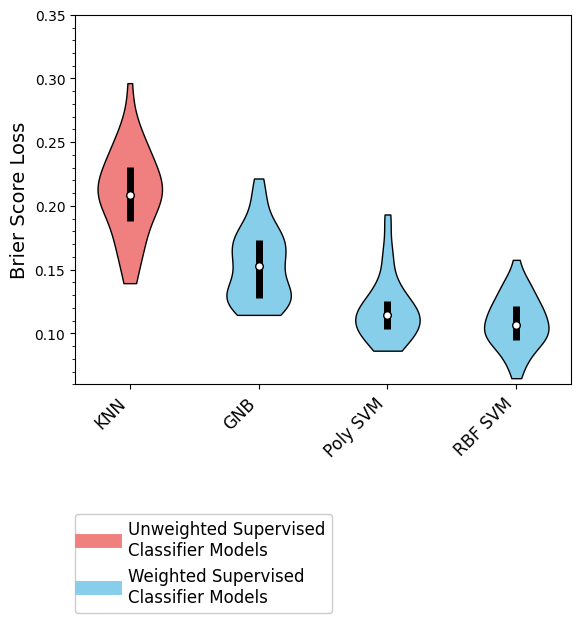

In [26]:
figsize=None#(10,4.8)

hide_unweighted = True

for plot_choice in plot_type:
        
        data_to_use_bsl = {x:brier_score_loss_dict[x] for x in brier_score_loss_dict if '(U)' not in x} if hide_unweighted else brier_score_loss_dict

        colours_to_use_bsl = [model_colour(x) for x in data_to_use_bsl.keys()]

        if hide_unweighted:
             data_to_use_bsl = {x.replace(' (W)',''):data_to_use_bsl[x] for x in data_to_use_bsl}

        fig, ax = plot_type[plot_choice](data_to_use_bsl,
                                         ylabel='Brier Score Loss',
                                         figsize=figsize,
                                         colours = colours_to_use_bsl
                                        #  savepath=f'{comparison_plots_output_folder}\\acc_comparison_with_pahs_{plot_choice}_{acc_type}.svg',
                                         )
        
        mlcf.set_axis_ticks(data_to_use_bsl,ax,'y',major_ticks_interval=0.05,
                            minor_ticks_interval=0.01,rounding=3,
                            upper_lim=0.35,lower_lim=0.06)

        if show_title:
            ax.set_title(f'Comparison of the Brier Score Loss\nbetween Classifier Models Including PAHs' if show_title else None,
                         fontsize=16)
            
        for c in boxplot_colors_dict:
            if boxplot_colors_dict[c] in colours_to_use_bsl:
                ax.plot([None], [None], c=boxplot_colors_dict[c], label=c, lw=10)

        ax.legend(framealpha=1,bbox_to_anchor=(0,-.35), loc='upper left', borderaxespad=0,fontsize=12)
        fig.savefig(f'{comparison_plots_output_folder}\\bsl_comparison_with_pahs_{plot_choice}.svg',
                    dpi=600, facecolor='#fff', bbox_inches='tight')